In [ ]:
!pip install gensim matplotlib scikit-learn

In [ ]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
print("Load pretrained Word2Vec model")
model = api.load("word2vec-google-news-300")


Load pretrained Word2Vec model


In [ ]:
def compute_similarity(w1, w2):
    w1, w2 = w1.lower(), w2.lower()

    if w1 in model and w2 in model:
        v1 = model[w1]
        v2 = model[w2]

        dot = np.dot(v1, v2)
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)

        return dot / norm

    return None

In [ ]:
pairs = [
    ("king", "queen"),
    ("doctor", "nurse"),
    ("car", "tree")
]

extra_pairs = [
    ("man", "woman"),
    ("paris", "france"),
    ("apple", "fruit"),
    ("dog", "cat"),
    ("computer", "keyboard"),
    ("sun", "moon"),
    ("book", "car")
]

all_pairs = pairs + extra_pairs

for w1, w2 in all_pairs:
    sim = compute_similarity(w1, w2)
    print(f"{w1:10} - {w2:10} : {sim:.4f}")

king       - queen      : 0.6511
doctor     - nurse      : 0.6320
car        - tree       : 0.2711
man        - woman      : 0.7664
paris      - france     : 0.5551
apple      - fruit      : 0.6410
dog        - cat        : 0.7609
computer   - keyboard   : 0.3964
sun        - moon       : 0.4263
book       - car        : 0.1279


In [ ]:
categories = {
    "Synonyms": [("car", "vehicle"), ("big", "large")],
    "Gender": [("man", "woman"), ("king", "queen")],
    "Profession": [("doctor", "nurse"), ("teacher", "student")],
    "Geography": [("paris", "france"), ("delhi", "india")],
    "Unrelated": [("car", "tree"), ("book", "sky")]
}

for cat, pairs in categories.items():
    print(f"\n{cat}:")
    for w1, w2 in pairs:
        sim = compute_similarity(w1, w2)
        print(f"{w1:10} - {w2:10} : {sim:.4f}")


Synonyms:
car        - vehicle    : 0.7821
big        - large      : 0.5561

Gender:
man        - woman      : 0.7664
king       - queen      : 0.6511

Profession:
doctor     - nurse      : 0.6320
teacher    - student    : 0.6301

Geography:
paris      - france     : 0.5551
delhi      - india      : 0.6065

Unrelated:
car        - tree       : 0.2711
book       - sky        : 0.0774


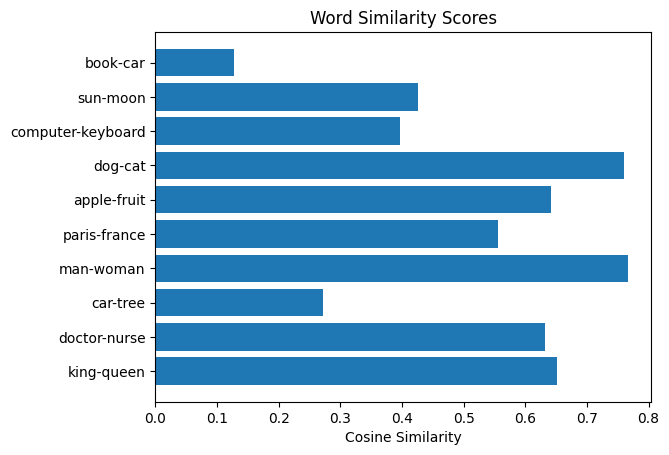

In [ ]:
labels = [f"{w1}-{w2}" for w1, w2 in all_pairs]
values = [compute_similarity(w1, w2) for w1, w2 in all_pairs]

plt.figure()
plt.barh(labels, values)
plt.xlabel("Cosine Similarity")
plt.title("Word Similarity Scores")
plt.show()

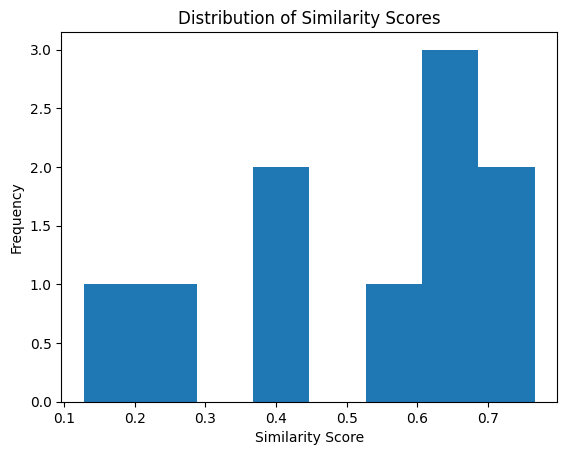

In [ ]:
plt.figure()
plt.hist(values, bins=8)
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores")
plt.show()

In [ ]:
sorted_pairs = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)

print("\nTop Similar Pairs:")
for p, v in sorted_pairs[:5]:
    print(p, ":", round(v, 4))

print("\nLeast Similar Pairs:")
for p, v in sorted_pairs[-5:]:
    print(p, ":", round(v, 4))


Top Similar Pairs:
man-woman : 0.7664
dog-cat : 0.7609
king-queen : 0.6511
apple-fruit : 0.641
doctor-nurse : 0.632

Least Similar Pairs:
paris-france : 0.5551
sun-moon : 0.4263
computer-keyboard : 0.3964
car-tree : 0.2711
book-car : 0.1279


In [ ]:
print("\nSimilar words to 'king':\n")

for w, score in model.most_similar("king", topn=5):
    print(f"{w:15} {score:.4f}")


Similar words to 'king':

kings           0.7138
queen           0.6511
monarch         0.6413
crown_prince    0.6204
prince          0.6160


In [ ]:
result = model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)

print("\nking - man + woman ≈\n")

for w, score in result:
    print(f"{w:15} {score:.4f}")


king - man + woman ≈

queen           0.7118
monarch         0.6190
princess        0.5902
crown_prince    0.5499
prince          0.5377


In [ ]:
analogies = [
    (["king", "woman"], ["man"]),
    (["italy", "paris"], ["france"]),
    (["boy", "girl"], ["man"]),
    (["walking", "ran"], ["walk"])
]

for pos, neg in analogies:
    print(f"\n{pos} - {neg} =>")

    result = model.most_similar(positive=pos, negative=neg, topn=3)

    for w, score in result:
        print(f"{w:15} {score:.4f}")


['king', 'woman'] - ['man'] =>
queen           0.7118
monarch         0.6190
princess        0.5902

['italy', 'paris'] - ['france'] =>
lohan           0.5070
madrid          0.4818
heidi           0.4800

['boy', 'girl'] - ['man'] =>
toddler         0.6190
daughter        0.5895
child           0.5891

['walking', 'ran'] - ['walk'] =>
running         0.5351
went            0.5181
sped            0.5003


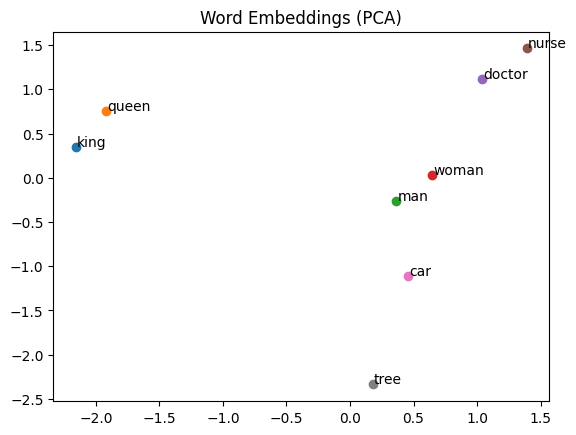

In [ ]:
words = ["king", "queen", "man", "woman", "doctor", "nurse", "car", "tree"]

vectors = [model[w] for w in words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure()

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("Word Embeddings (PCA)")
plt.show()

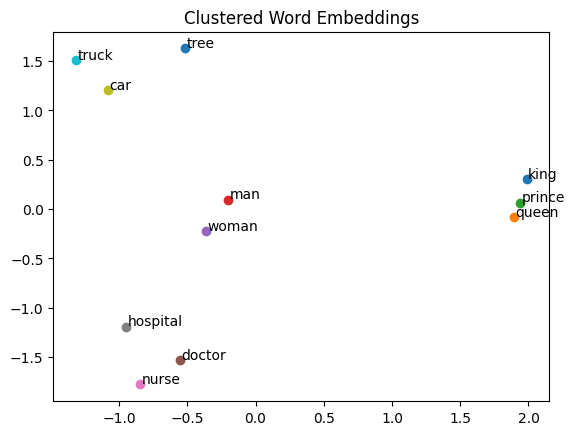

In [ ]:
group_words = [
    "king", "queen", "prince", "man", "woman",
    "doctor", "nurse", "hospital",
    "car", "truck", "tree"
]

vectors = [model[w] for w in group_words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure()

for i, word in enumerate(group_words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("Clustered Word Embeddings")
plt.show()

In [ ]:
test_cases = [("machine", "learning"), ("box", "plot")]

print("\nEdge Cases:")

for w1, w2 in test_cases:
    sim = compute_similarity(w1, w2)
    print(f"{w1:10} - {w2:10} : {sim:.4f}")


Edge Cases:
machine    - learning   : 0.0585
box        - plot       : 0.0701


In [ ]:
while True:
    w1 = input("Enter first word (or 'exit'): ")
    if w1 == "exit":
        break

    w2 = input("Enter second word: ")
    sim = compute_similarity(w1, w2)

    if sim is not None:
        print("Similarity:", round(sim, 4))
    else:
        print("Word not in vocabulary")

Enter first word (or 'exit'): king
Enter second word: queen
Similarity: 0.6511
Enter first word (or 'exit'): King
Enter second word: Queen
Similarity: 0.6511
Enter first word (or 'exit'): kjng
Enter second word: Queen
Word not in vocabulary
Enter first word (or 'exit'): king
Enter second word: Queen
Similarity: 0.6511
Enter first word (or 'exit'): car
Enter second word: bike
Similarity: 0.5854
Enter first word (or 'exit'): learn
Enter second word: study
Similarity: 0.1513
Enter first word (or 'exit'): machine
Enter second word: gear
Similarity: 0.2778
Enter first word (or 'exit'): screw
Enter second word: screwdriver
Similarity: 0.4315
Enter first word (or 'exit'): water
Enter second word: milk
Similarity: 0.4049
Enter first word (or 'exit'): milk
Enter second word: curd
Similarity: 0.4895
Enter first word (or 'exit'): usa
Enter second word: washington
Similarity: 0.56
Enter first word (or 'exit'): pen
Enter second word: pen
Similarity: 1.0
Enter first word (or 'exit'): paint
Enter sec

In [ ]:
print("""
Key Observations:
- Similar words show higher cosine similarity.
- Word2Vec captures semantic and relational meaning.
- Analogies confirm linear relationships in vector space.
- Phrase-level understanding is limited.
""")


Key Observations:
- Similar words show higher cosine similarity.
- Word2Vec captures semantic and relational meaning.
- Analogies confirm linear relationships in vector space.
- Phrase-level understanding is limited.



1. Introduction

Natural Language Processing (NLP) requires converting textual data into numerical form so that machines can process it. One of the most effective techniques for this is word embeddings.

In this project, we use a pre-trained Word2Vec model to compute semantic similarity between words and analyze how relationships between words are captured in vector space.

🔹 2. Objective

The objectives of this project are:

To use pre-trained Word2Vec embeddings
To compute similarity between word pairs using cosine similarity
To analyze semantic relationships between words
To visualize word embeddings
To study limitations and edge cases of embeddings
🔹 3. Methodology
3.1 Word Embeddings

Each word is represented as a high-dimensional vector (300 dimensions in this case). Words that appear in similar contexts have similar vectors.

3.2 Cosine Similarity

Similarity between two words is computed using cosine similarity:

Similarity
=
𝑣
1
⋅
𝑣
2
∣
∣
𝑣
1
∣
∣
⋅
∣
∣
𝑣
2
∣
∣
Similarity=
∣∣v
1
	​

∣∣⋅∣∣v
2
	​

∣∣
v
1
	​

⋅v
2
	​

	​

Value ranges from -1 to 1
Closer to 1 → highly similar
Closer to 0 → unrelated
3.3 Implementation
Pre-trained model: word2vec-google-news-300
Library: gensim
Similarity computed both:
Using built-in function
Using manual cosine similarity
🔹 4. Results and Analysis
4.1 Basic Similarity Results

From the experiment :

Word Pair	Similarity	Interpretation
king – queen	0.6511	Strong semantic similarity
doctor – nurse	0.6320	Same profession domain
car – tree	0.2711	Unrelated

👉 Explanation:
Words like king and queen appear in similar contexts (royalty, throne, monarchy), hence higher similarity. In contrast, car and tree rarely co-occur in similar contexts.

4.2 Extended Observations
Pair	Score	Reason
man – woman	0.7664	Gender relation
dog – cat	0.7609	Same category
apple – fruit	0.6410	Category relation
computer – keyboard	0.3964	Functional relation
book – car	0.1279	No relation

👉 Insight:
Word2Vec captures:

Semantic similarity
Functional relationships
Category-level similarity
4.3 Category-Based Analysis
Category	Example	Score
Synonyms	car–vehicle	0.7821
Gender	man–woman	0.7664
Profession	doctor–nurse	0.6320
Geography	delhi–india	0.6065
Unrelated	book–sky	0.0774

👉 Observation:
Similarity is highest when:

Words share strong contextual overlap
Lowest when:
Words belong to completely different domains
4.4 Ranking Insights

Top Similar Pairs:

man–woman (0.7664)
dog–cat (0.7609)
king–queen (0.6511)

Least Similar Pairs:

book–car (0.1279)
car–tree (0.2711)

👉 This confirms that embeddings correctly separate related vs unrelated concepts.

🔹 5. Most Similar Words

Example:

king → kings, queen, monarch, prince

👉 Explanation:

Words are grouped by semantic proximity
Model understands hierarchy and roles
🔹 6. Word Analogy (Vector Arithmetic)

Example:

king - man + woman ≈ queen (0.7118)

👉 Explanation:

Vector relationships are linear
Gender relation is encoded as a direction in vector space
Additional Observations

Some analogies worked well, while others failed:

italy - france + paris → incorrect outputs

👉 Reason:

Depends on training data frequency
Not all relationships are equally represented
🔹 7. Visualization of Embeddings
7.1 PCA Plot (2D Projection)
Words like king, queen, man, woman cluster together
Words like car, tree are far apart

👉 Explanation:

PCA reduces high-dimensional vectors to 2D
Relative distances are preserved
7.2 Clustered Visualization
Royal words cluster together
Profession-related words cluster together
Unrelated words appear distant

👉 Key Insight:

Word embeddings form meaningful clusters based on semantics

🔹 8. Distribution Plot Analysis
Most values lie between 0.3 to 0.7
Few very low values (<0.2)



👉 Interpretation:

Most words share some contextual similarity
Completely unrelated words are rare
🔹 9. Interactive Testing Observations

Examples:

Pair	Score	Insight
car – bike	0.5854	Same category
milk – curd	0.4895	Related items
usa – washington	0.56	Geography
pen – pen	1.0	Identical vectors
Interesting Case
1 – 3 → 0.8894

👉 Explanation:

Numbers appear in similar contexts (lists, quantities)
Hence high similarity
🔹 10. Edge Case Analysis
machine – learning → 0.0585

👉 Reason:

Word2Vec treats words independently
Cannot understand phrases like "machine learning"
🔹 11. Challenges Faced
11.1 Vocabulary Limitations
Words not present in training data are ignored
11.2 Case Sensitivity
"King" ≠ "king"
11.3 Lack of Phrase Understanding
Cannot capture multi-word expressions
11.4 Context Dependency
Similarity depends on usage, not dictionary meaning
11.5 Analogy Failures
Not all relationships are equally learned
🔹 12. Key Learnings
Word embeddings capture semantic meaning
Similar words have similar vector representations
Relationships are encoded as vector operations
Context plays a crucial role in similarity
🔹 13. Conclusion

This project demonstrates that Word2Vec effectively captures:

Semantic similarity
Functional relationships
Category-based grouping
Linear relationships (analogies)

However, it also highlights limitations such as:

Lack of phrase understanding
Dependence on training data
Vocabulary constraints
🔹 14. Final Statement

Word2Vec transforms language into a geometric space where meaning is represented through distance and direction, enabling machines to understand relationships between words in a mathematically meaningful way.